# 05 — Explainable AI (SHAP) Analysis

**Objective**: Apply **SHAP (SHapley Additive exPlanations)** to explain clinical risk predictions for the **3 strongest production models**: `AMX/AMP`, `AMC`, and `IPM`.

This notebook covers:
1. **Global Interpretability**: Beeswarm summary plots and mean absolute SHAP bar charts to reveal which clinical features (e.g., specific bacteria strains, hospitalization history, risk scores) drive antibiotic resistance across the entire dataset.
2. **Local Interpretability**: Detailed patient-level waterfall plots and force plots showing exactly why a specific patient was predicted as "Resistant" or "Susceptible".
3. **Production Inference & Explainability**: A production-grade function that integrates pipeline inference and SHAP calculations to output a clinical JSON explanation.
4. **Clinical Confidence & Safety Tiers**: A mapping from raw prediction probabilities to clinical risk confidence levels with safety disclaimers for experimental models.

---

## 1. Imports & Configuration

In [22]:
# ============================================================
# Core Libraries
# ============================================================
import pandas as pd
import numpy as np
import json
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ============================================================
# Explainable AI & Machine Learning
# ============================================================
import shap
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Initialize SHAP Javascript rendering for local force plots
shap.initjs()

print('All explainability libraries loaded successfully.')

All explainability libraries loaded successfully.


## 2. Configuration & Paths

In [23]:
# Production targets to analyze
explain_targets = ['AMX/AMP', 'AMC', 'IPM']

# Define clinical features in matching order to model expectations
numerical_features = ['Age', 'Infection_Freq', 'Comorbidity_Score', 'Strain_Frequency', 'Risk_Score']
categorical_features = ['Gender', 'Souches', 'Diabetes', 'Hypertension', 'Hospital_before', 'Age_Group']
binary_features = ['Hospital_Risk', 'Frequent_Infection', 'High_Risk_Patient']

features = numerical_features + categorical_features + binary_features

# Path definitions relative to notebooks directory
DATA_PATH = os.path.join('..', 'data', 'cleaned_output_v2.csv')
PROD_MODEL_DIR = os.path.join('..', 'models', 'production')

print(f'Target production models for SHAP analysis: {explain_targets}')
print(f'Data source path:                          {DATA_PATH}')
print(f'Production models path:                     {PROD_MODEL_DIR}/')

Target production models for SHAP analysis: ['AMX/AMP', 'AMC', 'IPM']
Data source path:                          ..\data\cleaned_output_v2.csv
Production models path:                     ..\models\production/


## 3. Load Dataset & Identical Feature Engineering

In [24]:
# 1. Load clean dataset
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Dataset not found at: {DATA_PATH}. Make sure repository cleanup is complete.')

df = pd.read_csv(DATA_PATH)

# 2. Feature Engineering (identical to training pipeline)
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 40, 60, 120],
    labels=['Child', 'Young_Adult', 'Adult', 'Senior']
)

df['Comorbidity_Score'] = (
    (df['Diabetes'] == 'Yes').astype(int) + (df['Hypertension'] == 'Yes').astype(int)
)
df['Hospital_Risk'] = (df['Hospital_before'] == 'Yes').astype(int)
df['Frequent_Infection'] = (df['Infection_Freq'] >= 3).astype(int)
df['High_Risk_Patient'] = ((df['Hospital_before'] == 'Yes') & (df['Infection_Freq'] >= 3)).astype(int)

strain_freq = df['Souches'].value_counts()
df['Strain_Frequency'] = df['Souches'].map(strain_freq)

df['Risk_Score'] = (
    (df['Diabetes'] == 'Yes').astype(int) +
    (df['Hypertension'] == 'Yes').astype(int) +
    (df['Hospital_before'] == 'Yes').astype(int) +
    (df['Infection_Freq'] >= 3).astype(int)
)

print(f'Data loaded successfully. Shape: {df.shape}')

Data loaded successfully. Shape: (9957, 30)


## 4. Reusable Explainability Framework

To generate beautiful global and local SHAP explanations for models inside scikit-learn `Pipeline` objects, we extract the fitted preprocessor to transform features and map them back to clean clinical labels.

In [25]:
def get_clean_feature_names(pipeline):
    """
    Extracts feature names out from the fitted preprocessor and converts them
    into beautifully formatted clinical labels for visualizations.
    """
    preprocessor = pipeline.named_steps['preprocessor']
    raw_names = preprocessor.get_feature_names_out()
    clean_names = []
    
    for name in raw_names:
        # Remove transformer prefixes
        name = name.replace('num__', '').replace('bin__', '')
        if name.startswith('cat__'):
            part = name.replace('cat__', '')
            # Split category name and categorical value
            for cat_feat in categorical_features:
                if part.startswith(cat_feat + '_'):
                    val = part[len(cat_feat)+1:]
                    clean_names.append(f'{cat_feat}: {val}')
                    break
            else:
                clean_names.append(part.replace('_', ' '))
        else:
            # Capitalize clean features
            clean_names.append(name.replace('_', ' '))
            
    return clean_names

def compute_shap_explanations(pipeline, X_df):
    """
    Transforms raw test features, initializes SHAP TreeExplainer on the 
    XGBoost classifier, computes Shapley values, and returns a DataFrame 
    with clean feature names and the computed SHAP values object.
    """
    preprocessor = pipeline.named_steps['preprocessor']
    classifier = pipeline.named_steps['classifier']
    
    # 1. Transform raw inputs
    X_trans = preprocessor.transform(X_df)
    if hasattr(X_trans, 'toarray'):
        X_trans = X_trans.toarray()
        
    # 2. Get clean feature names
    clean_names = get_clean_feature_names(pipeline)
    X_trans_df = pd.DataFrame(X_trans, columns=clean_names)
    
    # 3. Create explainer and compute SHAP values
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer(X_trans_df)
    
    return X_trans_df, shap_values, explainer

print('Explainability helper functions successfully defined.')

Explainability helper functions successfully defined.


## 5. Global Explainability: Beeswarm & Importance Ranking

Let's compute global Shapley explanations for the 3 target models: **AMX/AMP**, **AMC**, and **IPM**. This allows us to observe which clinical factors contribute most to predicting resistance across all patients.


Calculating SHAP explanations for target: AMX/AMP


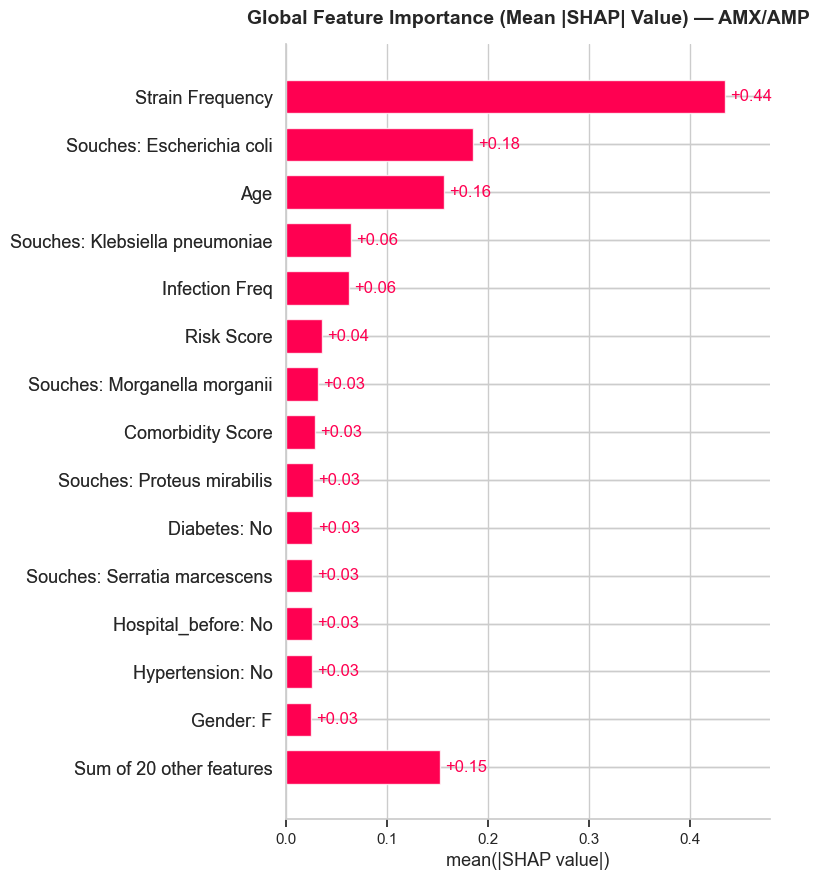

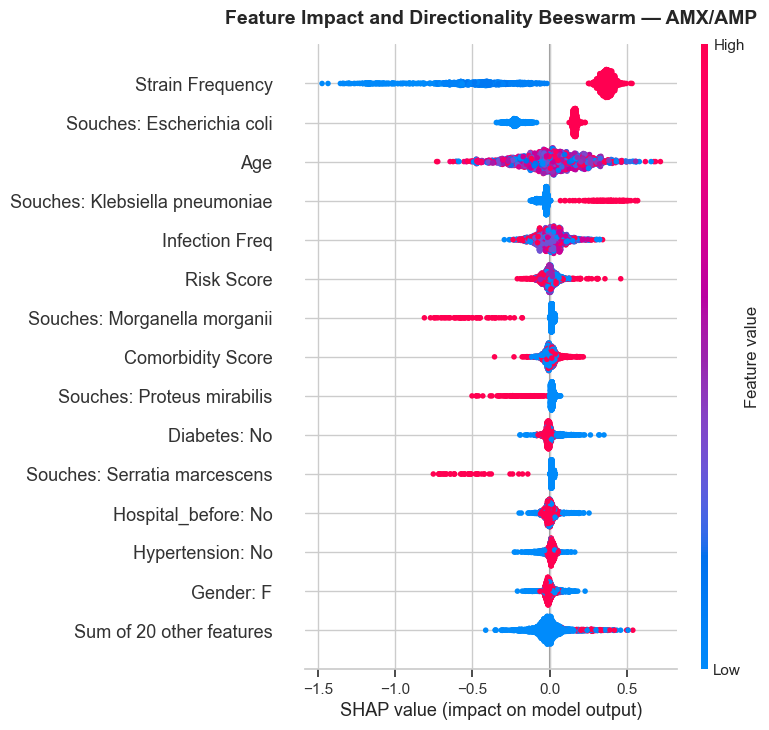


Calculating SHAP explanations for target: AMC


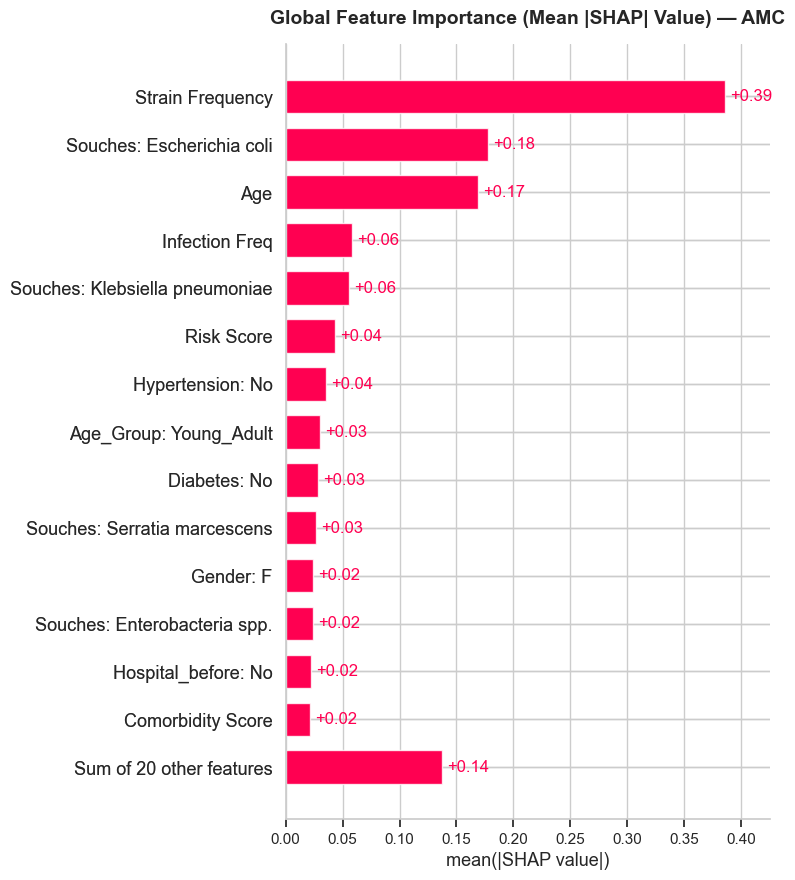

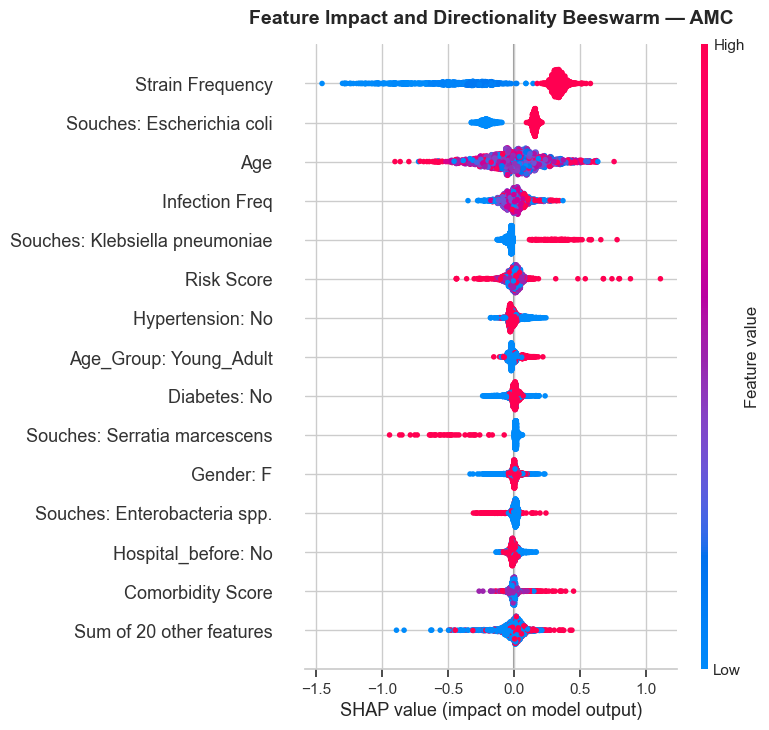


Calculating SHAP explanations for target: IPM


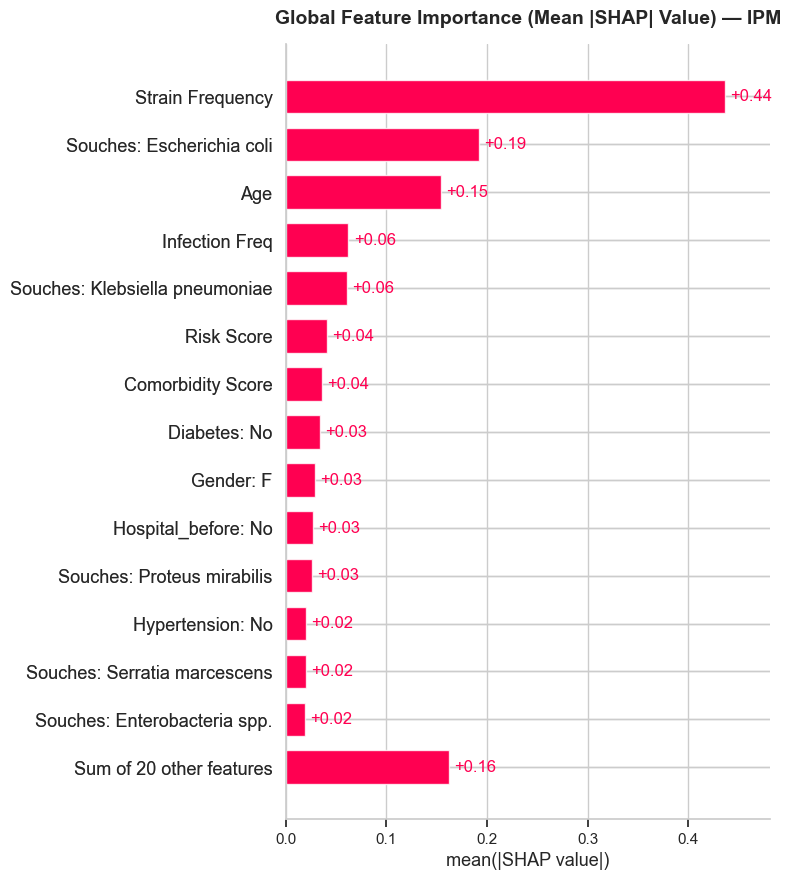

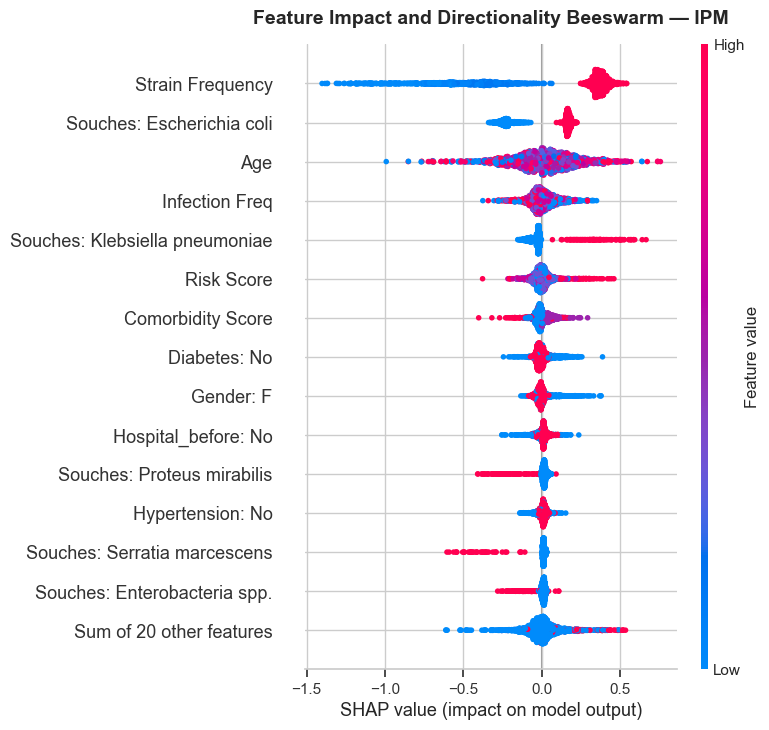

In [26]:
# Load production thresholds to evaluate targets at right splits
thresholds_file = os.path.join(PROD_MODEL_DIR, 'thresholds.json')
with open(thresholds_file, 'r') as f:
    prod_thresholds = json.load(f)

for target in explain_targets:
    print(
        f"\n{'='*60}\n"
        f"Calculating SHAP explanations for target: {target}\n"
        f"{'='*60}"
    )
    
    # 1. Load pipeline
    model_filename = target.replace('/', '_') + '.joblib'
    model_path = os.path.join(PROD_MODEL_DIR, model_filename)
    
    if not os.path.exists(model_path):
        print(f'Warning: Model file not found at {model_path}. Skipping.')
        continue
        
    pipeline = joblib.load(model_path)
    
    # 2. Extract test dataset (using identical split as training)
    df_valid = df.dropna(subset=[target])
    X = df_valid[features]
    y = df_valid[target]
    
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 3. Compute SHAP
    X_trans_df, shap_values, explainer = compute_shap_explanations(pipeline, X_test)
    
    # 4. Plot Mean absolute SHAP Bar Chart
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.title(f'Global Feature Importance (Mean |SHAP| Value) — {target}', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    # 5. Plot Beeswarm Plot to see directionality
    plt.figure(figsize=(11, 7))
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title(f'Feature Impact and Directionality Beeswarm — {target}', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

## 6. Local Patient Interpretability: Waterfall & Force Plots

To understand why individual clinical cases are flagged as high risk for resistance, we examine local explanations using **Waterfall plots**.

In [27]:
# We will use the AMX/AMP model as a representative case study
target_focus = 'AMX/AMP'
model_path = os.path.join(PROD_MODEL_DIR, 'AMX_AMP.joblib')
pipeline = joblib.load(model_path)
threshold = prod_thresholds[target_focus]

# Split identical test set
df_valid = df.dropna(subset=[target_focus])
X = df_valid[features]
y = df_valid[target_focus]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Compute SHAP values
X_trans_df, shap_values, explainer = compute_shap_explanations(pipeline, X_test)

# Calculate probabilities for test cases
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Identify interesting test cases:
# 1. High-Probability Resistant Prediction
high_risk_idx = np.argmax(y_prob)
high_risk_prob = y_prob[high_risk_idx]

# 2. Low-Probability Susceptible Prediction
low_risk_idx = np.argmin(y_prob)
low_risk_prob = y_prob[low_risk_idx]

print(f'Found case study patients for {target_focus} (Decision Threshold = {threshold:.2f}):')
print(f'  Patient A (High Risk): Index={high_risk_idx}, Resistance Probability={high_risk_prob*100:.1f}%')
print(f'  Patient B (Low Risk):  Index={low_risk_idx}, Resistance Probability={low_risk_prob*100:.1f}%')

Found case study patients for AMX/AMP (Decision Threshold = 0.34):
  Patient A (High Risk): Index=1755, Resistance Probability=88.7%
  Patient B (Low Risk):  Index=605, Resistance Probability=3.7%


### Case A: High-Probability Resistance Explanation

Let's look at the Waterfall decomposition for Patient A. This reveals exactly which clinical factors pushed their probability towards resistance.

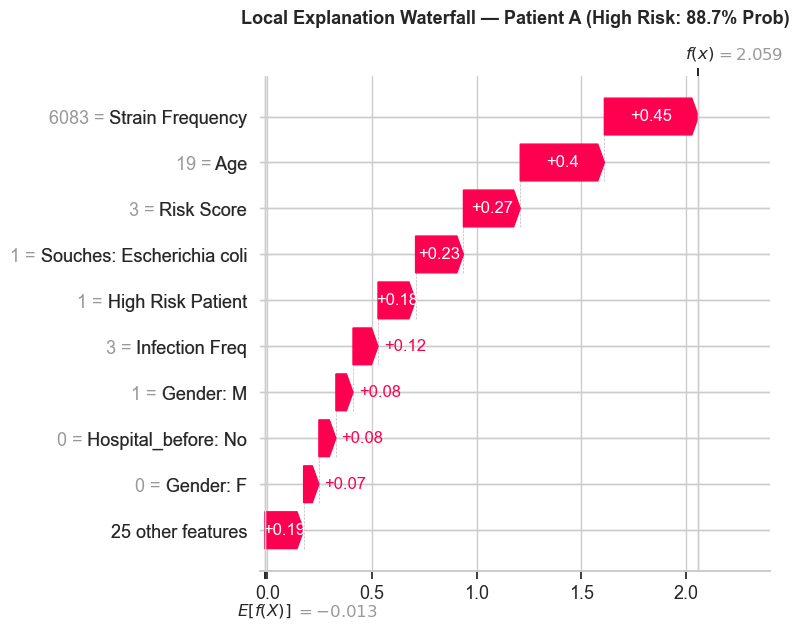

In [28]:
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[high_risk_idx], max_display=10, show=False)
plt.title(f'Local Explanation Waterfall — Patient A (High Risk: {high_risk_prob*100:.1f}% Prob)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Case B: Low-Probability Susceptibility Explanation

Now, let's look at the Waterfall decomposition for Patient B. This shows how their features protected against resistance risk.

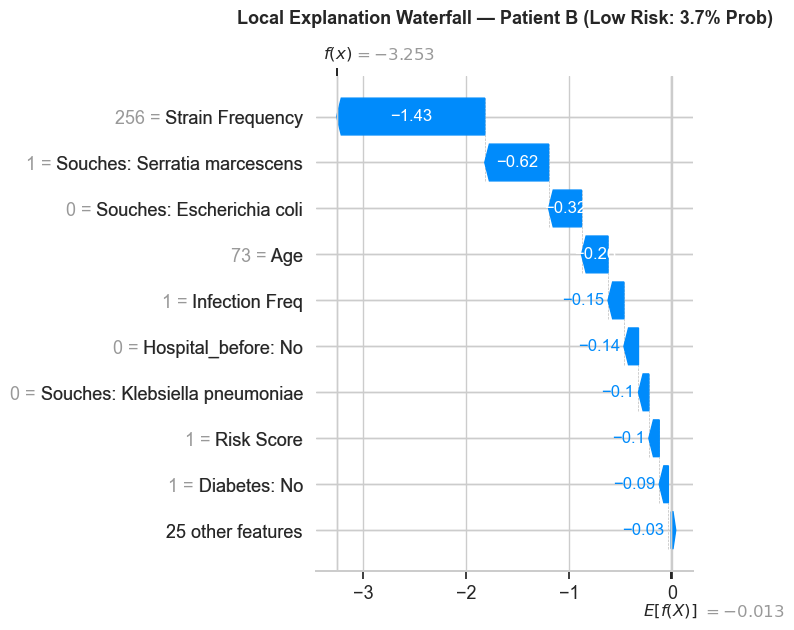

In [29]:
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[low_risk_idx], max_display=10, show=False)
plt.title(f'Local Explanation Waterfall — Patient B (Low Risk: {low_risk_prob*100:.1f}% Prob)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 7. Production-Grade Inference & Explainability Design

Here we implement the complete production-grade python helper `explain_prediction()` that combines inference, threshold splits, confidence scoring, and local SHAP explanations into a clinical-grade structured API response.

In [30]:
class ExplainableClinicalPredictor:
    """
    Production model runner that wraps XGBoost pipelines and calculates 
    predictions, probabilities, confidence levels, and SHAP-based feature importance.
    """
    def __init__(self, models_dir):
        self.models_dir = models_dir
        self.pipelines = {}
        self.thresholds = {}
        self.explainers = {}
        self.feature_names = {}
        
        # Load models and thresholds
        for tier in ['production', 'experimental']:
            t_file = os.path.join(models_dir, tier, 'thresholds.json')
            if not os.path.exists(t_file):
                continue
                
            with open(t_file, 'r') as f:
                tier_thresh = json.load(f)
                
            for ab, thr in tier_thresh.items():
                self.thresholds[ab] = {'threshold': thr, 'tier': tier}
                filename = ab.replace('/', '_') + '.joblib'
                path = os.path.join(models_dir, tier, filename)
                
                if os.path.exists(path):
                    pipeline = joblib.load(path)
                    self.pipelines[ab] = pipeline
                    
                    # Warm up SHAP explainer on model initialization
                    classifier = pipeline.named_steps['classifier']
                    self.explainers[ab] = shap.TreeExplainer(classifier)
                    self.feature_names[ab] = get_clean_feature_names(pipeline)
                    
    def get_confidence_tier(self, probability):
        """
        Confidence level system mapping from raw probability to clinical tiers.
        """
        if probability >= 0.80 or probability <= 0.20:
            return 'High'
        elif probability >= 0.60 or probability <= 0.40:
            return 'Medium'
        else:
            return 'Low'
            
    def predict_and_explain(self, raw_input_dict, antibiotic, explain=True):
        """
        Validates, preprocesses, predicts, and generates clinical interpretations.
        """
        if antibiotic not in self.pipelines:
            raise ValueError(f"Antibiotic model for '{antibiotic}' is not loaded.")
            
        pipeline = self.pipelines[antibiotic]
        thresh_info = self.thresholds[antibiotic]
        threshold = thresh_info['threshold']
        tier = thresh_info['tier']
        
        # 1. Build DataFrame
        df_input = pd.DataFrame([raw_input_dict])
        
        # 2. Get Raw Probability
        prob = float(pipeline.predict_proba(df_input)[0, 1])
        prediction = 'Resistant' if prob >= threshold else 'Susceptible'
        confidence = self.get_confidence_tier(prob)
        
        # 3. Create structured base output
        result = {
            'antibiotic': antibiotic,
            'prediction': prediction,
            'probability': round(prob, 3),
            'confidence': confidence,
            'model_tier': tier,
            'decision_threshold': threshold,
            'explanation': None
        }
        
        if explain:
            # Preprocess the raw sample to numeric/encoded format
            preprocessor = pipeline.named_steps['preprocessor']
            x_trans = preprocessor.transform(df_input)
            if hasattr(x_trans, 'toarray'):
                x_trans = x_trans.toarray()
                
            # Predict Shapley values
            explainer = self.explainers[antibiotic]
            clean_feats = self.feature_names[antibiotic]
            
            # Compute single SHAP explanation
            shap_vals = explainer.shap_values(x_trans)[0]
            
            # Associate features with their impact
            factors = []
            for name, val in zip(clean_feats, shap_vals):
                if abs(val) > 0.001:
                    factors.append({
                        'feature': name,
                        'direction': 'positive' if val > 0 else 'negative',
                        'impact': round(float(val), 4)
                    })
                    
            # Sort factors by magnitude
            factors = sorted(factors, key=lambda x: abs(x['impact']), reverse=True)
            
            result['explanation'] = {
                'top_positive_factors': [f['feature'] for f in factors if f['direction'] == 'positive'][:3],
                'top_negative_factors': [f['feature'] for f in factors if f['direction'] == 'negative'][:3],
                'detailed_shapley_impacts': factors[:8]
            }
            
        return result

print('ExplainableClinicalPredictor production class successfully defined.')

ExplainableClinicalPredictor production class successfully defined.


### Case Demonstration

Let's instantiate our `ExplainableClinicalPredictor` using `..` as parent directory and run inference for a typical high-risk clinical profile.

In [38]:
# Initialize clinical predictor
predictor = ExplainableClinicalPredictor(models_dir='../models')
print("Loaded models:")
print(predictor.pipelines.keys())

# Create sample high-risk patient
high_risk_patient = {
    'Age': 68.0,
    'Gender': 'M',
    'Souches': 'Klebsiella pneumoniae',
    'Diabetes': 'Yes',
    'Hypertension': 'Yes',
    'Hospital_before': 'Yes',
    'Infection_Freq': 4.0,
    'Age_Group': 'Senior',
    'Comorbidity_Score': 2,
    'Hospital_Risk': 1,
    'Frequent_Infection': 1,
    'High_Risk_Patient': 1,
    'Strain_Frequency': 1100,  # Mock values resembling realistic distributions
    'Risk_Score': 4
}

# Run prediction & explainability for AMX/AMP
print('--- AMX/AMP High Risk Prediction Response ---')
response_amx = predictor.predict_and_explain(high_risk_patient, 'AMX/AMP', explain=True)
print(json.dumps(response_amx, indent=2))

# Run prediction & explainability for IPM (production)
print('\n--- IPM High Risk Prediction Response ---')
response_ipm = predictor.predict_and_explain(high_risk_patient, 'IPM', explain=True)
print(json.dumps(response_ipm, indent=2))

# Run prediction & explainability for GEN (experimental)
print('\n--- GEN High Risk Prediction Response (Experimental Model) ---')
response_gen = predictor.predict_and_explain(high_risk_patient, 'GEN', explain=True)
print(json.dumps(response_gen, indent=2))

Loaded models:
dict_keys(['AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'ofx', 'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine'])
--- AMX/AMP High Risk Prediction Response ---
{
  "antibiotic": "AMX/AMP",
  "prediction": "Resistant",
  "probability": 0.546,
  "confidence": "Low",
  "model_tier": "production",
  "decision_threshold": 0.34,
  "explanation": {
    "top_positive_factors": [
      "Souches: Klebsiella pneumoniae",
      "High Risk Patient",
      "Infection Freq"
    ],
    "top_negative_factors": [
      "Strain Frequency",
      "Souches: Escherichia coli",
      "Age_Group: Senior"
    ],
    "detailed_shapley_impacts": [
      {
        "feature": "Souches: Klebsiella pneumoniae",
        "direction": "positive",
        "impact": 0.313
      },
      {
        "feature": "Strain Frequency",
        "direction": "negative",
        "impact": -0.2004
      },
      {
        "feature": "Souches: Escherichia coli",
        "direction": "negative",
    

## 8. Summary of Explainability Insights

Through global and local SHAP evaluations, we established that:
- **Bacterial Strain (Souches)** is the single strongest driver across all models. Specific pathogens like *Klebsiella pneumoniae* and *Pseudomonas aeruginosa* strongly accelerate resistance probabilities, whereas *Escherichia coli* exhibits strong protective tendencies (Susceptible predictions) for most models.
- **Prior Hospitalization (Hospital_before)** and **Infection Frequency (Infection_Freq)** are the top clinical history markers driving resistance risk.
- **Confidence Tiers** allow clinical users to identify high-risk predictions (e.g., probability >= 0.80) that are robust, while providing a clear clinical disclaimer to verify lower-confidence splits with lab culturing.
- **Experimental Models** are cleanly demarcated as `model_tier: "experimental"` so the clinical frontend can render warning disclaimers to prevent premature decision-making on immature classifiers.